[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Segment Videos with Segment Anything 3 (SAM3)

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-videos-with-segment-anything-3.ipynb) [![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/sam3/) [![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/facebookresearch/sam3)

SAM 3 (Segment Anything Model 3) extends the SAM series by moving from segmenting individual objects to understanding and segmenting all instances of a concept in images and videos. It introduces Promptable Concept Segmentation (PCS), where users specify a concept through short noun phrases like “striped cat” or by providing visual exemplars. The model detects, segments, and tracks every matching object, preserving identities across frames.


## Environment setup

### Configure your API keys

To pull Segment Anything 3 weights, you need a HuggingFace Access Token with approved access to the SAM 3 checkpoints.

- Request access to the SAM 3 checkpoints on the official Hugging Face [repo](https://huggingface.co/facebook/sam3).
- Open your HuggingFace Settings page. Click Access Tokens then New Token to generate a new token.
- In Colab, go to the left pane and click on Secrets (🔑). Store your HuggingFace Access Token under the name `HF_TOKEN`.



In [1]:
import os
from google.colab import userdata

# Enable expandable segments to reduce fragmentation
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [2]:
!nvidia-smi

Tue May 12 09:20:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             36W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True


### Install SAM 3 and extra dependencies

In [4]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content

fatal: destination path 'sam3' already exists and is not an empty directory.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15716 sha256=c19cb921b31947ad6e4f32448131cc00b5927551921719932dba3c6a2702002b
  Stored in directory: /tmp/pip-ephem-wheel-cache-751h7syg/wheels/7c/90/be/80339bb9db8655024d6c9501da4e5efc6abbda4c897f5a6c43
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0
/content


In [5]:
!pip install -q supervision jupyter_bbox_widget

In [6]:
!pip uninstall -y cc_torch; TORCH_CUDA_ARCH_LIST="8.0 9.0"; pip install git+https://github.com/ronghanghu/cc_torch
!pip uninstall -y torch_generic_nms; TORCH_CUDA_ARCH_LIST="8.0 9.0"; pip install git+https://github.com/ronghanghu/torch_generic_nms

Found existing installation: cc_torch 0.2
Uninstalling cc_torch-0.2:
  Successfully uninstalled cc_torch-0.2
  Cloning https://github.com/ronghanghu/cc_torch to /tmp/pip-req-build-pflsytsb
  Running command git clone --filter=blob:none --quiet https://github.com/ronghanghu/cc_torch /tmp/pip-req-build-pflsytsb
  Resolved https://github.com/ronghanghu/cc_torch to commit 446e9360ed10d3c8d03925ccb5f220ccb62009de
  Preparing metadata (setup.py) ... done
  Created wheel for cc_torch: filename=cc_torch-0.2-cp312-cp312-linux_x86_64.whl size=326037 sha256=7c84fdb0359190c3cf8ee7d19125a8312ffa9a9dcf04406971f138aea465e72c
  Stored in directory: /tmp/pip-ephem-wheel-cache-u_xlqhux/wheels/ec/00/d2/dd6e3f726591979dbc35c61d4feb785f48529310b422937236
Successfully built cc_torch
Found existing installation: torch_generic_nms 0.1
Uninstalling torch_generic_nms-0.1:
  Successfully uninstalled torch_generic_nms-0.1
  Cloning https://github.com/ronghanghu/torch_generic_nms to /tmp/pip-req-build-d3u2o1mb
  R

### Download example data

Downloads example videos. You can use these or replace them with your own videos.

In [7]:
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/jets-1280x720-1.mp4
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/jets-1280x720-2.mp4
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/jets-1280x720-3.mp4
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/go-karts-1280x720-3.mp4

<font color="red">⚠️ Restart session.</font>

## Imports

In [8]:
import cv2
import torch

import numpy as np
import supervision as sv

from pathlib import Path
from PIL import Image
from typing import Optional
from IPython.display import Video

from sam3.model_builder import build_sam3_video_predictor

In [9]:
HOME = Path.cwd()
print("HOME:", HOME)

HOME: /content


## Promptable Concept Segmentation (PCS)

### Load SAM3 model

In [10]:
# use all available GPUs on the machine
# DEVICES = range(torch.cuda.device_count())

# # use only a single GPU
DEVICES = [torch.cuda.current_device()]

In [11]:
predictor = build_sam3_video_predictor(bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz", gpus_to_use=DEVICES)

INFO 2026-05-12 09:23:49,259 19649 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-05-12 09:23:49,261 19649 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-05-12 09:23:49,262 19649 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-05-12 09:24:02,972 19649 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-05-12 09:24:19,882 19649 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-05-12 09:24:19,883 19649 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




### Process the video

SAM 3 assumee that the video is stored as a list of JPEG frames with filenames like `<frame_index>.jpg`. Let's start by downloading a sample video, splitting it into frames, and saving them to disk. Feel free to replace `SOURCE_VIDEO` with the path to your video file.

In [12]:
SOURCE_VIDEO = HOME / "jets-1280x720-3.mp4"
SOURCE_FRAMES = HOME / SOURCE_VIDEO.stem
SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)

!rm -rf {SOURCE_FRAMES}
!mkdir -p {SOURCE_FRAMES}

# !ffmpeg -i {SOURCE_VIDEO} -q:v 2 -start_number 0 {SOURCE_FRAMES}/'%05d.jpg'
!ffmpeg -i {SOURCE_VIDEO} -vf "scale=640:-1" -q:v 2 -start_number 0 {SOURCE_FRAMES}/'%05d.jpg'

response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=SOURCE_VIDEO.as_posix(), # Upewnij się, że ścieżka prowadzi do nowych klatek
    )
)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

frame loading (OpenCV) [rank=0]: 100%|██████████| 429/429 [00:05<00:00, 83.46it/s]
INFO 2026-05-12 09:24:35,707 19649 sam3_base_predictor.py: 146: started new session b77e1f16-521d-40af-b762-107f925b8986


In [13]:
def load_frame(directory: str, index: int):
    """
    Loads a frame with a specific index from a directory where frames are named
    using the pattern '%05d.jpg' (e.g., 00000.jpg, 00001.jpg, 00002.jpg).

    Args:
        directory (str): Path to the directory containing image frames.
        index (int): Frame index (0-based).

    Returns:
        numpy.ndarray: Loaded frame in BGR format.

    Raises:
        FileNotFoundError: If the frame does not exist or cannot be read.
    """
    directory_path = Path(directory)
    frame_path = directory_path / f"{index:05d}.jpg"

    if not frame_path.exists():
        raise FileNotFoundError(f"Frame not found: {frame_path}")

    frame = cv2.imread(str(frame_path))
    if frame is None:
        raise FileNotFoundError(f"Failed to load frame: {frame_path}")

    return frame

### Opening video inference session


SAM 3 requires stateful inference for interactive video segmentation, so we need to initialize an inference session on this video. During initialization, it loads all the JPEG frames in the video directory and stores their features in the session state.

In [14]:
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=SOURCE_VIDEO.as_posix(),
    )
)
session_id = response["session_id"]

frame loading (OpenCV) [rank=0]: 100%|██████████| 429/429 [00:05<00:00, 84.91it/s]
INFO 2026-05-12 09:24:44,441 19649 sam3_base_predictor.py: 146: started new session b458ffbf-fa1a-4661-85bf-5ffebc1f68eb


In [15]:
_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

### Adding a text prompt

Here we use the text prompt "person" to detect all people in the video. SAM 3 will automatically identify multiple person instances and assign each a unique object ID.

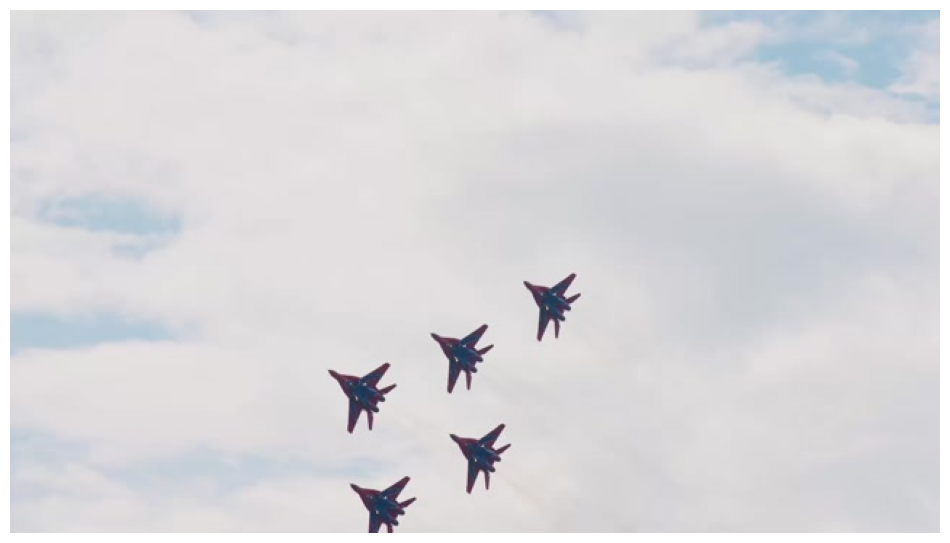

In [16]:
frame_idx = 0
frame = load_frame(SOURCE_FRAMES, frame_idx)

sv.plot_image(frame)

In [17]:
text = "jet"
response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=text,
    )
)
result = response["outputs"]

OutOfMemoryError: CUDA out of memory. Tried to allocate 46.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 35.81 MiB is free. Including non-PyTorch memory, this process has 14.53 GiB memory in use. Of the allocated memory 14.36 GiB is allocated by PyTorch, and 39.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Visualize results

In [ ]:
def from_sam(result: dict) -> sv.Detections:
    return sv.Detections(
        xyxy=sv.mask_to_xyxy(result["out_binary_masks"]),
        mask=result["out_binary_masks"],
        confidence=result["out_probs"],
        tracker_id=result["out_obj_ids"],
    )

In [ ]:
COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

def annotate(image: np.ndarray, detections: sv.Detections, text = None) -> np.ndarray:
    h, w, _ = image.shape
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=(w, h))

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.TRACK,
        opacity=0.6
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)

    if text:
        label_annotator = sv.LabelAnnotator(
            color=COLOR,
            color_lookup=sv.ColorLookup.TRACK,
            text_scale=text_scale,
            text_color=sv.Color.BLACK,
            text_position=sv.Position.TOP_CENTER,
            text_offset=(0, -30)
        )
        labels = [
            f"#{tracker_id} {text}"
            for tracker_id in detections.tracker_id
        ]
        annotated_image = label_annotator.annotate(annotated_image, detections, labels)

    return annotated_image

In [ ]:
detections = from_sam(result)

annotated_frame = annotate(frame, detections, text)

sv.plot_image(annotated_frame)

### Propagate in video

In [ ]:
def propagate_in_video(predictor, session_id):
    frame_outputs = {}
    # Clear cache before heavy processing
    torch.cuda.empty_cache()

    # Use inference_mode to save memory
    with torch.inference_mode():
        for response in predictor.handle_stream_request(
            request=dict(
                type="propagate_in_video",
                session_id=session_id,
            )
        ):
            frame_outputs[response["frame_index"]] = response["outputs"]

    return frame_outputs

In [ ]:
frame_outputs = propagate_in_video(predictor=predictor, session_id=session_id)

In [ ]:
TARGET_VIDEO = HOME / f"{SOURCE_VIDEO.stem}-result{SOURCE_VIDEO.suffix}"
TARGET_VIDEO_COMPRESSED = HOME / f"{TARGET_VIDEO.stem}-compressed{TARGET_VIDEO.suffix}"

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    annotated_frame = frame.copy()
    output = frame_outputs[index]
    detections = from_sam(output)
    return annotate(frame, detections, text)

sv.process_video(
    source_path=SOURCE_VIDEO,
    target_path=TARGET_VIDEO,
    callback=callback
)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED}

In [ ]:
Video(TARGET_VIDEO_COMPRESSED, embed=True, width=1080)

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>